<a href="https://colab.research.google.com/github/Khushimc/amazon-ml/blob/main/baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [3]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

 #leads to error
 import zipfile

zip_path = '/content/drive/MyDrive/dataset1/amazon_ml.zip'   # adjust if your zip name differs
extract_path = '/content/amazon_ml'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

import os
print(os.listdir(extract_path))   # list all files inside


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset1/amazon_ml.zip'

In [4]:
import os
print(os.listdir('/content/drive/MyDrive'))
print(os.listdir('/content/drive/MyDrive/dataset1'))


['Colab Notebooks', 'dataset1', 'Classroom', 'Quantum mechanics- Part 1.gdoc', 'IMG20241208164359 (2).jpg', 'IMG20241208164359 (1).jpg', 'Khushiii', 'IMG20241208164359.jpg', 'DOC-20250519-WA0026..pdf', 'idea.ppt.pptx.pdf', 'Screenshot_2025-10-28-10-27-56-58_6012fa4d4ddec268fc5c7112cbb265e7.jpg', 'Screenshot_2025-12-03-22-08-57-13_944a2809ea1b4cda6ef12d1db9048ed3.jpg', 'Untitled document (3).gdoc', 'Untitled document (2).gdoc', 'Devopsduplicate.docx', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'id card khushi.pdf', 'Khushi_resume.docx']
['amazon ml.zip']


In [5]:
import zipfile, os

zip_path = '/content/drive/MyDrive/dataset1/amazon ml.zip'   # note the space!
extract_path = '/content/amazon_ml'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))   # list extracted files


['__MACOSX', 'student_resource']


In [5]:

 #leads to error
 import pandas as pd
import glob

# find all TSV files inside the extracted folder
all_tsv = glob.glob(extract_path + "/*.tsv")
print(all_tsv)   # shows all file paths

# load the first TSV file
data = pd.read_csv(all_tsv[0], sep='\t')
print(data.shape)
data.head()


[]


IndexError: list index out of range

In [6]:
import os
print(os.listdir('/content/amazon_ml'))


['__MACOSX', 'student_resource']


In [7]:
print(os.listdir('/content/amazon_ml/student_resource'))


['.DS_Store', 'dataset', 'utils', 'README.md', 'Documentation_template.md']


In [8]:
import os

print(os.listdir('/content/amazon_ml/student_resource/dataset'))


['test', '.DS_Store', 'train']


In [9]:
print(os.listdir('/content/amazon_ml/student_resource/utils'))


['validate_submission.py']


In [10]:
import glob

all_tsv = glob.glob('/content/amazon_ml/student_resource/**/*.tsv', recursive=True)
print(all_tsv)   # should list all TSV file paths


['/content/amazon_ml/student_resource/dataset/test/test_source3.tsv', '/content/amazon_ml/student_resource/dataset/test/test_source1.tsv', '/content/amazon_ml/student_resource/dataset/test/test_source2.tsv', '/content/amazon_ml/student_resource/dataset/train/train_ground_truth.tsv', '/content/amazon_ml/student_resource/dataset/train/train_source3.tsv', '/content/amazon_ml/student_resource/dataset/train/train_source2.tsv', '/content/amazon_ml/student_resource/dataset/train/train_source1.tsv']


In [11]:
import pandas as pd

file_path = '/content/amazon_ml/student_resource/dataset/train/train_source1.tsv'
df = pd.read_csv(file_path, sep='\t')

print(df.shape)
df.head()


(2206821, 4)


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


In [12]:
import glob

train_files = glob.glob('/content/amazon_ml/student_resource/dataset/train/*.tsv')
train_dfs = [pd.read_csv(f, sep='\t') for f in train_files]

train_data = pd.concat(train_dfs, ignore_index=True)
print(train_data.shape)
train_data.head()


(14733861, 6)


,source1_entity_id,matched_entity_ids,entity_id,business_name,business_address,country
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129...",NaN,NaN,NaN,NaN
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843...",NaN,NaN,NaN,NaN
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467",NaN,NaN,NaN,NaN
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215",NaN,NaN,NaN,NaN
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280...",NaN,NaN,NaN,NaN


In [13]:
test_files = glob.glob('/content/amazon_ml/student_resource/dataset/test/*.tsv')
test_dfs = [pd.read_csv(f, sep='\t') for f in test_files]

test_data = pd.concat(test_dfs, ignore_index=True)
print(test_data.shape)
test_data.head()


(11702133, 4)


,entity_id,business_name,business_address,country
0,S3-462677478,मॉडर्न फाइनेंस,"No 10 Enkay Square, 448A, Udyog Vihar Phase V,...",India
1,S3-374810425,Shri Sai Infratech Co,"3/115, East Delhi, DL",India
2,S3-198586129,Fractales Amis Groupe S.A.S,"23 Rue Icmre, La Teste-de-buch, Gironde",France
3,S3-10300249,Shri Supreme Consulting Private (Limited),"H.no 910 A 3503, Mumbai, महाराष्ट्र",India
4,S3-604980231,Prime Realty Ventures Public Limited,"G.t. Karnal Road, Industrial Area, New Delhi, ...",India


In [14]:
import pandas as pd

# Example: load one train file
train_source1 = pd.read_csv('/content/amazon_ml/student_resource/dataset/train/train_source1.tsv', sep='\t')

# Basic info
print(train_source1.info())
print(train_source1.describe())

# Missing values
print(train_source1.isnull().sum())

# Duplicates
print(train_source1.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2206821 entries, 0 to 2206820
Data columns (total 4 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   entity_id         object
 1   business_name     object
 2   business_address  object
 3   country           object
dtypes: object(4)
memory usage: 67.3+ MB
None
           entity_id       business_name                   business_address  \
count        2206821             2206821                            2206821   
unique       2206821             1539229                            2130606   
top     S1-252639948  Primary Care Group  108 Norle Street, College Twp, PA   
freq               1                 253                                 14   

        country  
count   2206821  
unique        2  
top          US  
freq    1323633  
entity_id           0
business_name       0
business_address    0
country             0
dtype: int64
0


In [15]:
# error
train_source1 = train_source1.drop_duplicates()

# Handle missing values (example: fill with median for numeric columns)
for col in train_source1.select_dtypes(include='number').columns:
    train_source1[col] = train_source1[col].fillna(train_source1[col].median())

# For categorical columns, fill with mode
for col in train_source1.select_dtypes(include='object').columns:
    train_source1[col] = train_source1[col].fillna(train_source1[col].mode()[0])

# Normalize numeric features (optional)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_source1_scaled = scaler.fit_transform(train_source1.select_dtypes(include='number'))


ValueError: at least one array or dtype is required

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load one train file as example
train_source1 = pd.read_csv('/content/amazon_ml/student_resource/dataset/train/train_source1.tsv', sep='\t')

# Detect numeric and categorical columns
numeric_cols = train_source1.select_dtypes(include='number').columns
cat_cols = train_source1.select_dtypes(include='object').columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(cat_cols))

# Scale numeric columns only if they exist
if len(numeric_cols) > 0:
    scaler = StandardScaler()
    train_source1[numeric_cols] = scaler.fit_transform(train_source1[numeric_cols])
else:
    print("No numeric columns found to scale.")

# Encode categorical columns
for col in cat_cols:
    le = LabelEncoder()
    train_source1[col] = le.fit_transform(train_source1[col].astype(str))

print("Preprocessed dataframe:")
print(train_source1.head())


Numeric columns: []
Categorical columns: ['entity_id', 'business_name', 'business_address', 'country']
No numeric columns found to scale.
Preprocessed dataframe:
   entity_id  business_name  business_address  country
0    2024204         989181            368964        1
1    1652787        1081079            362544        1
2     681650         121917            351630        1
3      80654         265875            475359        1
4    1607210        1061718           1193929        0


In [ ]:
 #leads to error
 import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numeric features
if len(numeric_cols) > 0:
    train_source1[numeric_cols].hist(figsize=(12,8))
    plt.show()

# Countplots for categorical features
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=train_source1[col])
    plt.title(f'Distribution of {col}')
    plt.show()

# Correlation heatmap (only if numeric features exist)
if len(numeric_cols) > 0:
    plt.figure(figsize=(10,6))
    sns.heatmap(train_source1[numeric_cols].corr(), annot=True, cmap='coolwarm')
    plt.show()


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7a5af60bb6a0> (for post_execute):


KeyboardInterrupt: 

In [1]:
 #leads to error
sample_df = train_source1.sample(n=5000, random_state=42)  # adjust n as needed


NameError: name 'train_source1' is not defined

In [16]:
import pandas as pd

train_source1 = pd.read_csv('/content/amazon_ml/student_resource/dataset/train/train_source1.tsv', sep='\t')


In [17]:
# Work with a sample to avoid RAM crashes
sample_df = train_source1.sample(n=5000, random_state=42)


In [18]:
import matplotlib.pyplot as plt

numeric_cols = sample_df.select_dtypes(include='number').columns

if len(numeric_cols) > 0:
    sample_df[numeric_cols].hist(figsize=(12,8))
    plt.show()


In [28]:
 #leads to error
import seaborn as sns

cat_cols = sample_df.select_dtypes(include='object').columns

for col in cat_cols[:5]:   # limit to first 5 categorical features
    plt.figure(figsize=(6,4))
    sns.countplot(x=sample_df[col])
    plt.title(f'Distribution of {col} (sample)")
    plt.show()


SyntaxError: unterminated f-string literal (detected at line 8) (723245626.py, line 8)

In [6]:
 #leads to error
for col in cat_cols[:5]:   # limit to first 5 categorical features
    plt.figure(figsize=(6,4))
    sns.countplot(x=sample_df[col])
    plt.title(f'Distribution of {col} (sample)')
    plt.show()


NameError: name 'cat_cols' is not defined

In [19]:
numeric_cols = train_source1.select_dtypes(include='number').columns
cat_cols = train_source1.select_dtypes(include='object').columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: []
Categorical columns: ['entity_id', 'business_name', 'business_address', 'country']


In [20]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(sample_df[col].value_counts().head(10))  # top 10 categories



Column: entity_id
entity_id
S1-528827404    1
S1-53356671     1
S1-320151505    1
S1-938947364    1
S1-195839862    1
S1-655046555    1
S1-758070915    1
S1-169338169    1
S1-651717089    1
S1-176638896    1
Name: count, dtype: int64

Column: business_name
business_name
Equinox LLC                         3
South Developers Private Limited    3
Oncology Group                      3
Cobalt                              3
Division of Consumer Affairs        2
Regional Dental Associates          2
Uptown Book Store                   2
Family Associates LLC               2
Star Investments Private Limited    2
Pediatric Dentistry Group           2
Name: count, dtype: int64

Column: business_address
business_address
6151 Shadow Lane, Unit APT 216, Citrus Heights, CA                                                               1
4850 20, Otisco, NY                                                                                              1
19034 Woodburn Road, Woodburn, IN                

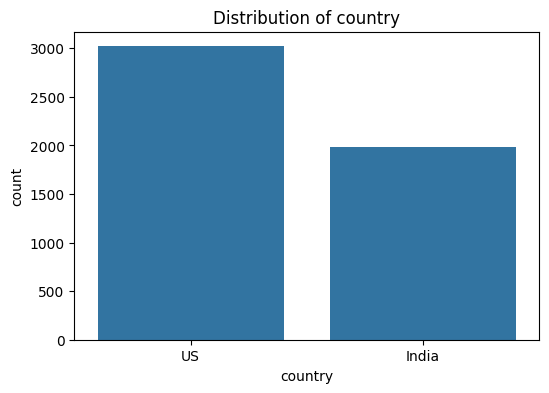

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in cat_cols:
    if sample_df[col].nunique() < 20:   # only plot if fewer than 20 unique values
        plt.figure(figsize=(6,4))
        sns.countplot(x=sample_df[col])
        plt.title(f'Distribution of {col}')
        plt.show()


In [10]:
 #leads to error
 ground_truth = pd.read_csv('/content/amazon_ml/student_resource/dataset/train/train_ground_truth.tsv', sep='\t')

# Merge with source1 on entity_id (adjust if your key is different)
train_data = ground_truth.merge(train_source1, on='entity_id')

print(train_data.head())
print(train_data['label'].value_counts())  # replace 'label' with actual target column name


KeyError: 'entity_id'

In [22]:

 #leads to error
 print("Ground truth columns:", ground_truth.columns.tolist())
print("Train source1 columns:", train_source1.columns.tolist())


NameError: name 'ground_truth' is not defined

In [23]:

 #leads to error
 train_data = ground_truth.merge(
    train_source1,
    left_on='source1_entity_id',
    right_on='entity_id'
)

print(train_data.head())
print(train_data.shape)
print(train_data['matched_entity_ids'].value_counts())  # target distribution


NameError: name 'ground_truth' is not defined

In [22]:
print(train_data['matched_entity_ids'].value_counts())


matched_entity_ids
S2-271844502,S3-998262924                                          1
S2-681193310,S2-743505751,S3-775321672,S3-11291185,S3-860443364    1
S2-249013014,S2-197070651,S3-478195123,S3-384364074                1
S2-790675320,S2-479876582,S3-878454467                             1
S2-153058913,S2-24659151,S3-679606215                              1
                                                                  ..
S2-356983532,S3-352439310                                          1
S2-383871912,S3-74481402,S3-576451439                              1
S2-648035184,S3-588502663                                          1
S3-274817120,S3-312496301                                          1
S2-660036492,S3-804600254                                          1
Name: count, Length: 2083574, dtype: int64


In [1]:
 #leads to error
for col in ['business_name', 'business_address', 'country']:
    train_data[col] = pd.factorize(train_data[col])[0]



NameError: name 'pd' is not defined

In [6]:
 #leads to error
from sklearn.model_selection import train_test_split

X = train_data.drop(columns=['matched_entity_ids', 'source1_entity_id', 'entity_id'])
y = train_data['matched_entity_ids']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


NameError: name 'train_data' is not defined

In [16]:
 #leads to error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


ValueError: Input contains NaN

In [5]:
 #leads to error
print(train_data.isnull().sum())


NameError: name 'train_data' is not defined

In [3]:
# leads to error
train_data = train_data.dropna(subset=['matched_entity_ids'])

print(train_data.shape)   # check new size
print(train_data['matched_entity_ids'].value_counts())


NameError: name 'train_data' is not defined

In [23]:

train_data = train_data.dropna(subset=['matched_entity_ids'])
print(train_data.shape)


(2083574, 6)


In [24]:
train_data_small = train_data.sample(n=10000, random_state=42)


In [25]:
for col in ['business_name', 'business_address', 'country']:
    train_data_small[col] = pd.factorize(train_data_small[col])[0]


In [26]:
from sklearn.model_selection import train_test_split

X = train_data_small.drop(columns=['matched_entity_ids', 'source1_entity_id', 'entity_id'])
y = train_data_small['matched_entity_ids']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier(random_state=42, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


Accuracy: 0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

                                                                                                                      precision    recall  f1-score   support

                                                                              S2-100013935,S2-533337810,S3-422852605       0.00      0.00      0.00       0.0
                                                                                            S2-100248831,S3-85173160       0.00      0.00      0.00       1.0
                                       S2-101071823,S2-951953355,S2-675896366,S3-263720678,S3-273408868,S3-402653265       0.00      0.00      0.00       1.0
                                                    S2-101554446,S2-689487194,S3-614606444,S3-460182209,S3-280216681       0.00      0.00      0.00       1.0
                                                                 S2-101881311,S2-664419923,S3-272843332,S3-892915353       0.00      0.00      0.00       1.0
                                                   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
